# Factores que determinan el ingreso laboral en Colombia
## Notebook 02 — Análisis exploratorio (EDA)

**Fuente de datos:** [GEIH 2025 — DANE](https://microdatos.dane.gov.co/index.php/catalog/853)
**Datos de entrada:** Dataset limpio generado en el Notebook 01 (geih_limpio.csv)
**Autora:** Katherin Liceth Reyes Enciso

## Contexto

En el Notebook 01 cargamos los datos de la Gran Encuesta Integrada de Hogares (GEIH) del primer semestre de 2025, cruzamos las tablas de Ocupados y Características Generales, limpiamos registros con ingreso nulo o cero, filtramos mayores de 18 años y transformamos los códigos numéricos en categorías legibles.

El resultado fue un dataset limpio con 169,472 registros y 24 columnas, guardado en `geih_limpio.csv`.

## Objetivo de este notebook

Responder las 11 preguntas de investigación planteadas en el Notebook 01 mediante análisis estadístico y visualizaciones. El objetivo es identificar qué factores (educación, sexo, sector, zona, tipo de contrato, posición ocupacional, horas trabajadas y antigüedad) tienen mayor influencia en el ingreso laboral de los colombianos.

### Nota metodológica

Se verificó que la mediana del ingreso es consistente en los 6 meses analizados (entre \$1,300,000 y \$1,423,500), lo que valida la agregación del semestre completo para obtener muestras más robustas. Enero presenta una mediana ligeramente menor, posiblemente por efectos estacionales de inicio de año.

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import plotly.express as px
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Carga de datos

Cargamos el dataset limpio generado en el Notebook 01.

In [73]:


# Cargar dataset limpio
datos = pd.read_csv('/content/drive/MyDrive/Factores que determinan el ingreso laboral en Colombia/geih_limpio.csv')

print(f'Filas: {len(datos):,}')
print(f'Columnas: {datos.shape[1]}')
print(f'\nColumnas disponibles:')
print(datos.columns.tolist())

Filas: 169,472
Columnas: 24

Columnas disponibles:
['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'HOGAR', 'MES', 'CLASE', 'DEPARTAMENTO', 'FEX_C18', 'INGLABO', 'HORAS_SEMANA', 'SECTOR_ECONOMICO', 'POSICION', 'TIENE_CONTRATO', 'TIPO_CONTRATO', 'DURACION_CONTRATO', 'COTIZA_PENSION', 'TIENE_ARL', 'ANTIGUEDAD_MESES', 'TAMAÑO_EMPRESA', 'SEXO', 'EDAD', 'NIVEL_EDUCATIVO', 'LATITUD', 'LONGITUD']


### Pregunta 1: ¿Cómo se distribuye el ingreso laboral en Colombia?

Analizamos cómo se distribuye el ingreso laboral (INGLABO) entre los ocupados, agrupando a las personas según cuántos salarios mínimos legales vigentes (SMLV 2025: $1.623.500) ganan al mes. Esto nos permite ver en qué rangos de ingreso se concentra la mayor parte de los trabajadores.

In [74]:
print('=== ESTADÍSTICAS DEL INGRESO LABORAL ===')
print(f'Promedio:    ${datos["INGLABO"].mean():,.0f}')
print(f'Mediana:     ${datos["INGLABO"].median():,.0f}')
print(f'Mínimo:      ${datos["INGLABO"].min():,.0f}')
print(f'Máximo:      ${datos["INGLABO"].max():,.0f}')
print(f'Desv. est.:  ${datos["INGLABO"].std():,.0f}')

print(f'\nPercentiles:')
for p in [10, 25, 50, 75, 90, 95]:
    valor = datos['INGLABO'].quantile(p/100)
    print(f'  P{p}: ${valor:,.0f}')

=== ESTADÍSTICAS DEL INGRESO LABORAL ===
Promedio:    $1,746,413
Mediana:     $1,423,500
Mínimo:      $1
Máximo:      $103,000,000
Desv. est.:  $2,238,339

Percentiles:
  P10: $400,000
  P25: $800,000
  P50: $1,423,500
  P75: $1,850,000
  P90: $3,200,000
  P95: $4,800,000


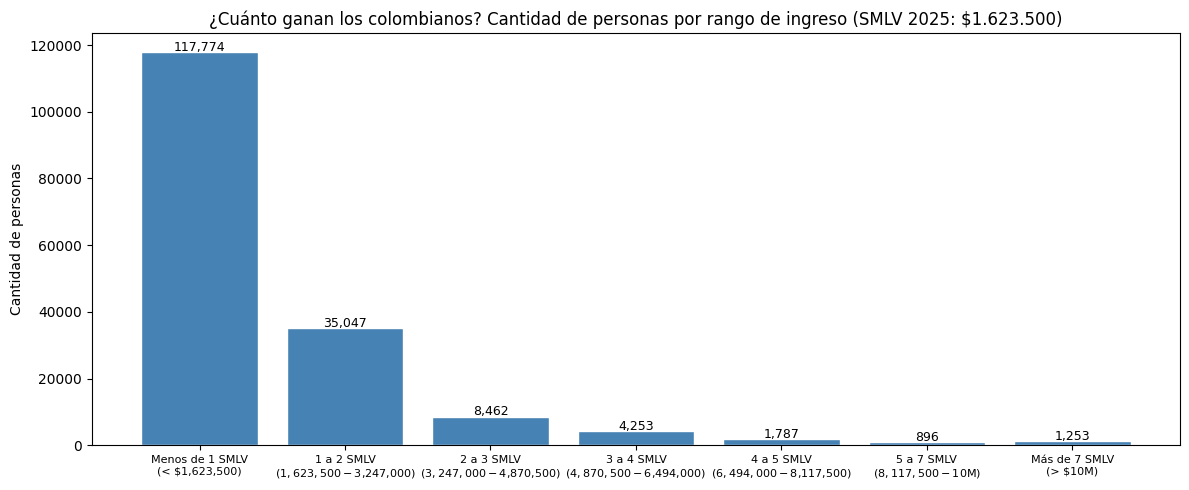

In [75]:
smlv = 1_623_500

bins = [0, smlv, smlv*2, smlv*3, smlv*4, smlv*5, 10_000_000, float('inf')]
labels = [
    f'Menos de 1 SMLV\n(< ${smlv:,.0f})',
    f'1 a 2 SMLV\n(${smlv:,.0f} - ${smlv*2:,.0f})',
    f'2 a 3 SMLV\n(${smlv*2:,.0f} - ${smlv*3:,.0f})',
    f'3 a 4 SMLV\n(${smlv*3:,.0f} - ${smlv*4:,.0f})',
    f'4 a 5 SMLV\n(${smlv*4:,.0f} - ${smlv*5:,.0f})',
    f'5 a 7 SMLV\n(${smlv*5:,.0f} - $10M)',
    'Más de 7 SMLV\n(> $10M)'
]

datos['RANGO_INGRESO'] = pd.cut(datos['INGLABO'], bins=bins, labels=labels)
conteo = datos['RANGO_INGRESO'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(range(len(conteo)), conteo.values, color='steelblue', edgecolor='white')

for i, v in enumerate(conteo.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

ax.set_xticks(range(len(conteo)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('¿Cuánto ganan los colombianos? Cantidad de personas por rango de ingreso (SMLV 2025: $1.623.500)')
ax.set_ylabel('Cantidad de personas')

plt.tight_layout()
plt.show()

#### Hallazgos

Para el primer semestre de 2025, la mayoría de los trabajadores colombianos ganan menos de un salario mínimo legal vigente (\$1.423.500), contando el auxilio de transporte (\$200.000). La mediana del ingreso laboral coincide prácticamente con el SMLV, lo que significa que la mitad de los ocupados gana un salario mínimo o menos.

Esto nos lleva a preguntarnos: ¿qué factores hacen que una persona gane más o menos? ¿Influye el nivel educativo? ¿El sexo? ¿El sector económico? ¿El tipo de contrato? En las siguientes secciones intentaremos responder estas preguntas.

### Pregunta 2: ¿El nivel educativo se refleja en el ingreso?

Comparamos el ingreso laboral mediano según el nivel educativo de las personas para ver si estudiar más se traduce en ganar más.

In [76]:
orden_educacion = [
    'Ninguno', 'Preescolar', 'Básica primaria', 'Básica secundaria',
    'Media académica', 'Media técnica', 'Normalista',
    'Técnica profesional', 'Tecnológica', 'Universitaria',
    'Especialización', 'Maestría', 'Doctorado'
]

resumen = datos.groupby('NIVEL_EDUCATIVO').agg(
    cantidad=('INGLABO', 'count'),
    minimo=('INGLABO', 'min'),
    mediana=('INGLABO', 'median'),
    promedio=('INGLABO', 'mean'),
    maximo=('INGLABO', 'max')
).reindex(orden_educacion)

resumen['minimo'] = resumen['minimo'].apply(lambda x: f'${x:,.0f}')
resumen['mediana'] = resumen['mediana'].apply(lambda x: f'${x:,.0f}')
resumen['promedio'] = resumen['promedio'].apply(lambda x: f'${x:,.0f}')
resumen['maximo'] = resumen['maximo'].apply(lambda x: f'${x:,.0f}')

print(resumen.to_string())

                     cantidad    minimo     mediana    promedio        maximo
NIVEL_EDUCATIVO                                                              
Ninguno                4279.0    $8,000    $600,000    $726,987   $23,600,000
Preescolar               13.0   $90,000    $500,000    $710,615    $2,680,000
Básica primaria           NaN      $nan        $nan        $nan          $nan
Básica secundaria         NaN      $nan        $nan        $nan          $nan
Media académica       54044.0       $40  $1,400,000  $1,334,550  $100,000,000
Media técnica          4182.0   $10,000  $1,423,500  $1,489,305   $26,000,000
Normalista              256.0   $40,000  $1,423,500  $1,727,441    $8,000,000
Técnica profesional   15917.0       $40  $1,423,500  $1,628,784   $80,000,000
Tecnológica            7454.0   $20,000  $1,571,500  $1,895,332   $60,400,000
Universitaria         27429.0       $30  $2,000,000  $2,741,603  $100,000,000
Especialización        5909.0  $100,000  $4,100,000  $5,134,717 

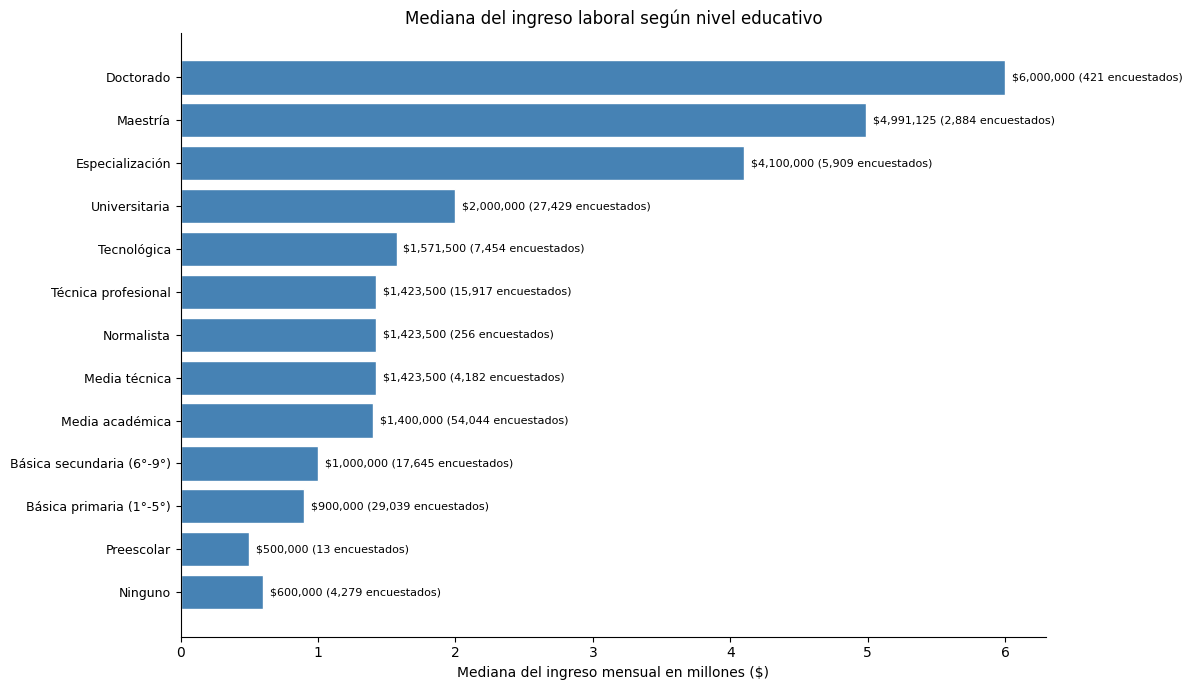

In [77]:
orden_educacion = [
    'Ninguno', 'Preescolar', 'Básica primaria (1°-5°)', 'Básica secundaria (6°-9°)',
    'Media académica', 'Media técnica', 'Normalista',
    'Técnica profesional', 'Tecnológica', 'Universitaria',
    'Especialización', 'Maestría', 'Doctorado'
]

resumen = datos.groupby('NIVEL_EDUCATIVO').agg(
    mediana_ingreso=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
).reindex(orden_educacion)

fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.barh(range(len(resumen)), resumen['mediana_ingreso'] / 1_000_000,
                 color='steelblue', edgecolor='white')

for i, (ingreso, cantidad) in enumerate(zip(resumen['mediana_ingreso'], resumen['cantidad'])):
    ax.text(ingreso / 1_000_000 + 0.05, i, f'${ingreso:,.0f} ({cantidad:,} encuestados)',
            va='center', fontsize=8)

ax.set_yticks(range(len(resumen)))
ax.set_yticklabels(resumen.index, fontsize=9)
ax.set_xlabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral según nivel educativo')

# Solo dejar ejes X y Y
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

El nivel educativo tiene una relación directa con el ingreso: a mayor formación, mayor ingreso. Una persona con doctorado tiene una mediana de ingreso de \$6.000.000, casi 7 veces más que una persona con básica primaria ($900,000).

Sin embargo, solo a partir de nivel universitario ($2,000,000) la mediana del ingreso supera el SMLV + auxilio de transporte (\$1,623,500). Todos los niveles por debajo, que representan la mayoría de los encuestados tienen una mediana igual o inferior al salario mínimo.

Esto se conecta directamente con lo que encontramos en la Pregunta 1: la mayoría de los trabajadores gana menos de un SMLV porque la mayoría tiene un nivel educativo de Media académica o inferior. Solo los niveles de Media académica (54,044), Básica primaria (29,039) y Básica secundaria (17,645) suman más de 100,000 personas, es decir, más del 59% de los encuestados. Y en todos estos niveles la mediana del ingreso está en $1,400,000 o menos.

En resumen: estudiar más sí se refleja en el ingreso, pero la mayoría de la fuerza laboral colombiana no tiene la formación suficiente para superar el salario mínimo.

### Pregunta 3: ¿Existe diferencia salarial entre hombres y mujeres?

Comparamos la mediana del ingreso laboral entre hombres y mujeres para identificar si existe una brecha salarial por sexo.

In [78]:
resumen_sexo = datos.groupby('SEXO').agg(
    mediana_ingreso=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
)

print('=== MEDIANA DEL INGRESO POR SEXO ===')
for sexo, row in resumen_sexo.iterrows():
    print(f'  {sexo}: ${row["mediana_ingreso"]:,.0f} ({row["cantidad"]:,} encuestados)')

brecha = resumen_sexo.loc['Hombre', 'mediana_ingreso'] - resumen_sexo.loc['Mujer', 'mediana_ingreso']
brecha_pct = (brecha / resumen_sexo.loc['Hombre', 'mediana_ingreso']) * 100
print(f'\nDiferencia: ${brecha:,.0f}')
print(f'Las mujeres ganan {brecha_pct:.1f}% menos que los hombres')


=== MEDIANA DEL INGRESO POR SEXO ===
  Hombre: $1,423,500 (94,835.0 encuestados)
  Mujer: $1,400,000 (74,637.0 encuestados)

Diferencia: $23,500
Las mujeres ganan 1.7% menos que los hombres


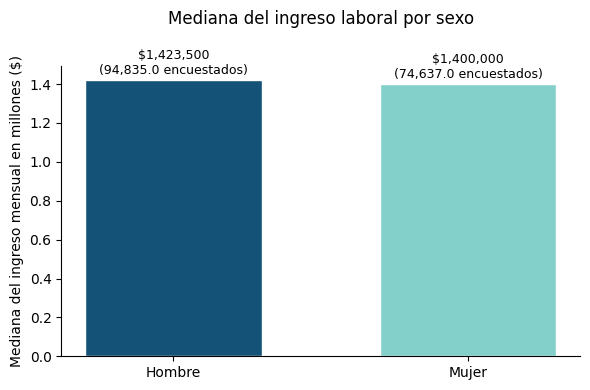

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))

colores = ['#145277', '#83d0cb']
barras = ax.bar(resumen_sexo.index, resumen_sexo['mediana_ingreso'] / 1_000_000,
                color=colores, edgecolor='white', width=0.6)

for i, (sexo, row) in enumerate(resumen_sexo.iterrows()):
    ax.text(i, row['mediana_ingreso'] / 1_000_000 + 0.03,
            f'${row["mediana_ingreso"]:,.0f}\n({row["cantidad"]:,} encuestados)',
            ha='center', fontsize=9)

ax.set_ylabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral por sexo', pad=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

A nivel general, la diferencia entre la mediana del ingreso de hombres (\$1,423,500) y mujeres (\$1,400,000) es de apenas \$23,500, lo que representa un 1.7%. Esta diferencia es mínima y no permite afirmar que exista una brecha salarial significativa entre hombres y mujeres a nivel agregado.

Sin embargo, este resultado puede estar ocultando diferencias dentro de grupos específicos. Por ejemplo, ¿la diferencia sigue siendo mínima si comparamos hombres y mujeres con el mismo nivel educativo? Eso es lo que analizamos en la siguiente pregunta.

### Pregunta 4: ¿Se mantiene esa diferencia al controlar por nivel educativo?

En la pregunta anterior vimos que la brecha general es mínima (1.7%). Pero ¿qué pasa si comparamos hombres y mujeres dentro del mismo nivel educativo? Así eliminamos el efecto de que un grupo tenga más estudios que otro.

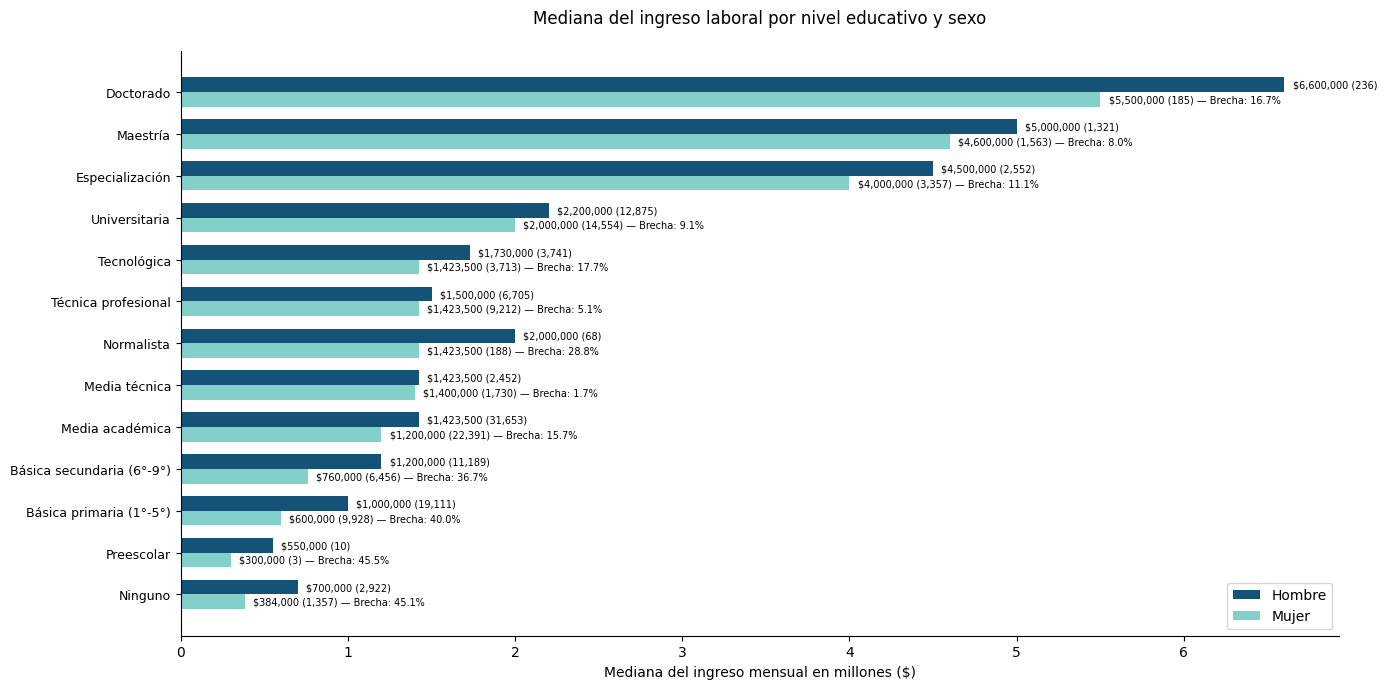

In [80]:
resumen_completo = datos.groupby(['NIVEL_EDUCATIVO', 'SEXO']).agg(
    mediana=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
).unstack()
resumen_completo = resumen_completo.reindex(orden_educacion)

orden_educacion = [
    'Ninguno', 'Preescolar', 'Básica primaria (1°-5°)', 'Básica secundaria (6°-9°)',
    'Media académica', 'Media técnica', 'Normalista',
    'Técnica profesional', 'Tecnológica', 'Universitaria',
    'Especialización', 'Maestría', 'Doctorado'
]
resumen = datos.groupby(['NIVEL_EDUCATIVO', 'SEXO'])['INGLABO'].median().unstack()
resumen = resumen.reindex(orden_educacion)

resumen['Diferencia'] = resumen['Hombre'] - resumen['Mujer']
resumen['Brecha %'] = (resumen['Diferencia'] / resumen['Hombre'] * 100).round(1)
fig, ax = plt.subplots(figsize=(14, 7))

y = range(len(resumen_completo))
alto = 0.35

ax.barh([i + alto/2 for i in y], resumen_completo['mediana']['Hombre'] / 1_000_000,
        height=alto, color='#145277', label='Hombre')
ax.barh([i - alto/2 for i in y], resumen_completo['mediana']['Mujer'] / 1_000_000,
        height=alto, color='#83d0cb', label='Mujer')

for i, nivel in enumerate(resumen_completo.index):
    h_ing = resumen_completo.loc[nivel, ('mediana', 'Hombre')]
    m_ing = resumen_completo.loc[nivel, ('mediana', 'Mujer')]
    h_cant = resumen_completo.loc[nivel, ('cantidad', 'Hombre')]
    m_cant = resumen_completo.loc[nivel, ('cantidad', 'Mujer')]
    brecha = (h_ing - m_ing) / h_ing * 100

    # Hombre: dato en frente de su barra
    ax.text(h_ing / 1_000_000 + 0.05, i + alto/2,
            f'${h_ing:,.0f} ({int(h_cant):,})', va='center', fontsize=7)

    # Mujer: dato + brecha en frente de su barra
    ax.text(m_ing / 1_000_000 + 0.05, i - alto/2,
            f'${m_ing:,.0f} ({int(m_cant):,}) — Brecha: {brecha:.1f}%', va='center', fontsize=7)

ax.set_yticks(y)
ax.set_yticklabels(resumen_completo.index, fontsize=9)
ax.set_xlabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral por nivel educativo y sexo', pad=20)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

Aunque en la Pregunta 3 la brecha general era de apenas 1.7%, al controlar por nivel educativo la realidad es muy diferente: **en todos los niveles educativos las mujeres ganan menos que los hombres, sin excepción.**

Las brechas más grandes se concentran en los niveles educativos más bajos: Preescolar (45.5%), Ninguno (45.1%), Básica primaria (40.0%) y Básica secundaria (36.7%). Esto sugiere que las mujeres con menor formación enfrentan una doble desventaja: ganan poco por su nivel educativo y además ganan significativamente menos que los hombres en la misma situación.

A medida que aumenta el nivel educativo, la brecha tiende a reducirse pero no desaparece. En los niveles técnico y tecnológico va del 5.1% al 17.7%, y en posgrado se mantiene entre el 8% y el 16.7%.

Pero esto nos genera una pregunta: ¿la brecha se debe a que ser mujer implica ganar menos, o a que hombres y mujeres trabajan en posiciones diferentes? Veamos cómo se distribuyen por posición ocupacional.

In [81]:
tabla_completa = datos.groupby('POSICION').agg(
    Hombres=('SEXO', lambda x: (x == 'Hombre').sum()),
    Pct_Hombres=('SEXO', lambda x: round((x == 'Hombre').sum() / (datos['SEXO'] == 'Hombre').sum() * 100, 1)),
    Mujeres=('SEXO', lambda x: (x == 'Mujer').sum()),
    Pct_Mujeres=('SEXO', lambda x: round((x == 'Mujer').sum() / (datos['SEXO'] == 'Mujer').sum() * 100, 1)),
).sort_values('Hombres', ascending=False)

# Mediana por posición y sexo
mediana_sexo = datos.groupby(['POSICION', 'SEXO'])['INGLABO'].median().unstack()

tabla_completa['Mediana Hombres'] = mediana_sexo['Hombre']
tabla_completa['Mediana Mujeres'] = mediana_sexo['Mujer']
tabla_completa['Brecha'] = ((mediana_sexo['Hombre'] - mediana_sexo['Mujer']) / mediana_sexo['Hombre'] * 100).round(1)

tabla_completa = tabla_completa.sort_values('Mediana Hombres', ascending=False)

tabla_completa['Pct_Hombres'] = tabla_completa['Pct_Hombres'].apply(lambda x: f'{x}%')
tabla_completa['Pct_Mujeres'] = tabla_completa['Pct_Mujeres'].apply(lambda x: f'{x}%')
tabla_completa['Mediana Hombres'] = tabla_completa['Mediana Hombres'].apply(lambda x: f'${x:,.0f}')
tabla_completa['Mediana Mujeres'] = tabla_completa['Mediana Mujeres'].apply(lambda x: f'${x:,.0f}')
tabla_completa['Brecha'] = tabla_completa['Brecha'].apply(lambda x: f'{x}%')

tabla_completa.columns = ['Hombres', '% Hombres', 'Mujeres', '% Mujeres',
                           'Mediana H', 'Mediana M', 'Brecha']
tabla_completa

,Hombres,% Hombres,Mujeres,% Mujeres,Mediana H,Mediana M,Brecha
POSICION,,,,,,,
Empleado gobierno,4338,4.6%,4642,6.2%,"$3,700,000","$3,800,000",-2.7%
Patrón o empleador,2479,2.6%,1190,1.6%,"$2,200,000","$2,000,000",9.1%
Empleado particular,40183,42.4%,33007,44.2%,"$1,450,000","$1,423,500",1.8%
Empleado doméstico,368,0.4%,5542,7.4%,"$1,423,000","$880,000",38.2%
Jornalero o peón,3589,3.8%,351,0.5%,"$1,200,000","$800,000",33.3%
Cuenta propia,43852,46.2%,29865,40.0%,"$1,000,000","$650,000",35.0%
Otro,26,0.0%,40,0.1%,"$675,000","$400,000",40.7%


#### Conclusión sobre la brecha salarial

Los datos confirman que la brecha salarial entre hombres y mujeres existe en casi todas las posiciones ocupacionales, pero con diferencias importantes:

**La única posición donde las mujeres ganan más que los hombres es Empleado gobierno** (brecha de -2.7%), donde las mujeres tienen una mediana de \$3.800.000 frente a \$3.700.000 de los hombres. Esto puede explicarse porque el sector público tiene escalas salariales más estandarizadas.

**Las brechas más grandes se dan en las posiciones más informales:** Otro (40.7%), Empleado doméstico (38.2%), Cuenta propia (35.0%) y Jornalero o peón (33.3%). Precisamente las posiciones donde hay menos regulación salarial.

**El empleo doméstico merece atención especial:** el 7.4% de las mujeres ocupadas son empleadas domésticas frente a solo el 0.4% de los hombres, y además dentro de esa misma posición las mujeres ganan \$880,000 frente a \$1,423,000 de los hombres. Es decir, no solo hay más mujeres en esta posición de bajo ingreso, sino que dentro de ella les pagan menos.

**Cuenta propia concentra la mayor cantidad de trabajadores** (43,852 hombres y 29,865 mujeres) y presenta una brecha del 35%: los hombres ganan \$1,000,000 y las mujeres \$650,000. Dado que esta es la posición con más personas, tiene un peso enorme en la brecha general.

**Empleado particular es la posición con menor brecha** (1.8%), lo que sugiere que las empresas privadas formales tienden a ofrecer salarios más equitativos.

En resumen: la brecha salarial de género se amplifica por dos factores simultáneos. Primero, las mujeres están sobrerrepresentadas en posiciones de menor ingreso como el empleo doméstico. Segundo, dentro de una misma posición, las mujeres ganan menos que los hombres, especialmente en las posiciones más informales y menos reguladas.

### Pregunta 5: ¿Qué sectores económicos pagan más?

Comparamos la mediana del ingreso laboral por sector económico para identificar cuáles son los que mejor y peor pagan a sus trabajadores.

In [82]:
resumen_sector = datos.groupby('SECTOR_ECONOMICO').agg(
    Encuestados=('INGLABO', 'count'),
    Mediana_ingreso=('INGLABO', 'median')
).sort_values('Mediana_ingreso', ascending=False)

resumen_sector['Mediana_ingreso'] = resumen_sector['Mediana_ingreso'].apply(lambda x: f'${x:,.0f}')

resumen_sector

,Encuestados,Mediana_ingreso
SECTOR_ECONOMICO,,
Actividades de organizaciones y entidades extraterritoriales,45,"$3,200,000"
Administración pública y defensa; planes de seguridad social de afiliación obligatoria,7520,"$3,000,000"
Educación,8948,"$2,847,000"
"Suministro de electricidad, gas, vapor y aire acondicionado",767,"$2,000,000"
"Actividades profesionales, científicas y técnicas",4748,"$2,000,000"
Actividades financieras y de seguros,2662,"$2,000,000"
Información y comunicaciones,2349,"$1,900,000"
Actividades de atención de la salud humana y de asistencia social,9000,"$1,700,000"
No clasificado,4,"$1,570,000"


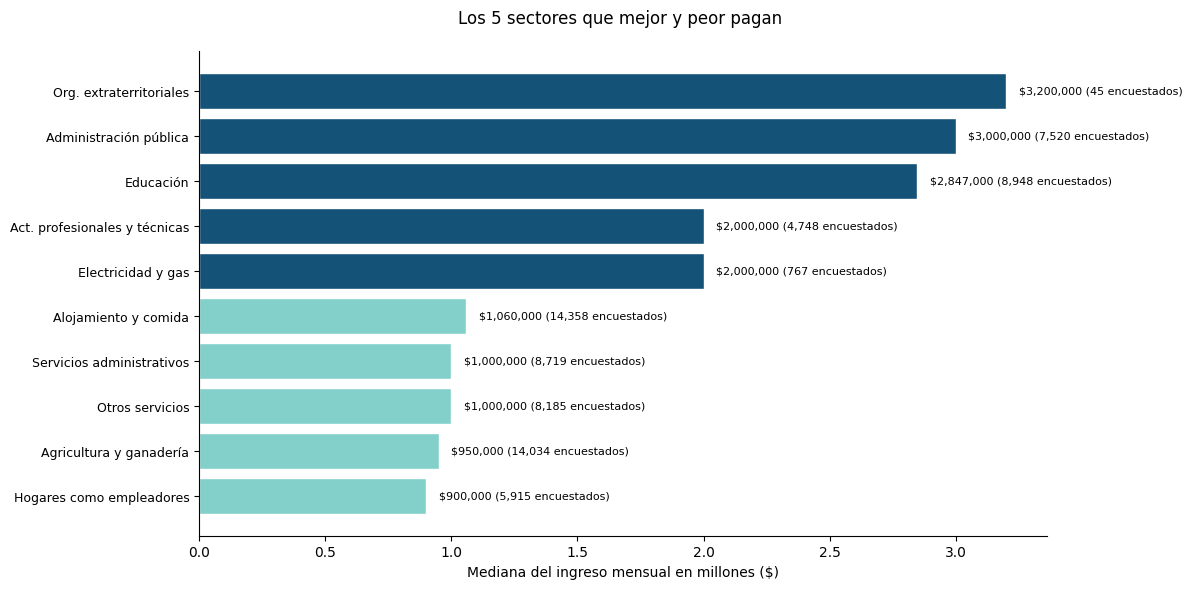

In [83]:
resumen_graf = datos.groupby('SECTOR_ECONOMICO').agg(
    mediana_ingreso=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
).sort_values('mediana_ingreso', ascending=False)

# Top 5 y Bottom 5
top5 = resumen_graf.head(5)
bottom5 = resumen_graf.tail(5)
seleccion = pd.concat([top5, bottom5]).sort_values('mediana_ingreso', ascending=True)

# Nombres cortos para el gráfico
nombres_cortos = {
    'Actividades de organizaciones y entidades extraterritoriales': 'Org. extraterritoriales',
    'Administración pública y defensa; planes de seguridad social de afiliación obligatoria': 'Administración pública',
    'Educación': 'Educación',
    'Actividades profesionales, científicas y técnicas': 'Act. profesionales y técnicas',
    'Suministro de electricidad, gas, vapor y aire acondicionado': 'Electricidad y gas',
    'Actividades de los hogares en calidad de empleadores; actividades no diferenciadas de los hogares individuales como productores de bienes y servicios para uso propio': 'Hogares como empleadores',
    'Agricultura, ganadería, caza, silvicultura y pesca': 'Agricultura y ganadería',
    'Actividades de servicios administrativos y de apoyo': 'Servicios administrativos',
    'Otras actividades de servicios': 'Otros servicios',
    'Alojamiento y servicios de comida': 'Alojamiento y comida',
}

etiquetas = [nombres_cortos.get(s, s) for s in seleccion.index]
colores = ['#83d0cb' if i < 5 else '#145277' for i in range(len(seleccion))]

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(range(len(seleccion)), seleccion['mediana_ingreso'] / 1_000_000,
        color=colores, edgecolor='white')

for i, (ingreso, cantidad) in enumerate(zip(seleccion['mediana_ingreso'], seleccion['cantidad'])):
    ax.text(ingreso / 1_000_000 + 0.05, i,
            f'${ingreso:,.0f} ({cantidad:,} encuestados)', va='center', fontsize=8)

ax.set_yticks(range(len(seleccion)))
ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_xlabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Los 5 sectores que mejor y peor pagan ', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [84]:
resumen_raw = datos.groupby('SECTOR_ECONOMICO').agg(
    cantidad=('INGLABO', 'count'),
    mediana=('INGLABO', 'median')
)

bajo_smlv = resumen_raw[resumen_raw['mediana'] <= smlv]
sobre_smlv = resumen_raw[resumen_raw['mediana'] > smlv]

total_bajo = bajo_smlv['cantidad'].sum()
total_sobre = sobre_smlv['cantidad'].sum()
pct_bajo = total_bajo / (total_bajo + total_sobre) * 100

print(f'Sectores con mediana <= SMLV: {len(bajo_smlv)}')
print(f'Trabajadores en esos sectores: {total_bajo:,} ({pct_bajo:.1f}%)')
print(f'\nSectores con mediana > SMLV: {len(sobre_smlv)}')
print(f'Trabajadores en esos sectores: {total_sobre:,} ({100-pct_bajo:.1f}%)')

Sectores con mediana <= SMLV: 14
Trabajadores en esos sectores: 133,433 (78.7%)

Sectores con mediana > SMLV: 8
Trabajadores en esos sectores: 36,039 (21.3%)


#### Hallazgos

De los 22 sectores económicos, 14 tienen una mediana de ingreso igual o inferior al salario mínimo ($1,423,500). Estos 14 sectores concentran el 78.7% de los trabajadores encuestados (133,433 personas), lo que significa que casi 8 de cada 10 colombianos trabaja en un sector donde la mitad o más de sus trabajadores no alcanza a ganar un salario mínimo.

Los 8 sectores que superan el salario mínimo (administración pública, educación, actividades profesionales, financieras, entre otros) representan solo el 21.3% de los ocupados. Estos sectores comparten dos características: exigen mayor formación académica y ofrecen empleos más formales.

Esto refuerza el patrón que venimos encontrando: no es solo que las personas con menor educación ganan menos, sino que los sectores donde trabajan son los que peor pagan, creando un ciclo de bajo ingreso difícil de romper.

### Pregunta 6: ¿La zona (cabecera/resto) afecta el ingreso?

Comparamos la mediana del ingreso laboral entre las personas que viven en cabecera y resto para ver si la ubicación geográfica influye en cuánto gana una persona.

In [85]:
resumen_zona = datos.groupby('CLASE').agg(
    mediana_ingreso=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
)

print('=== MEDIANA DEL INGRESO POR CLASE ===')
for zona, row in resumen_zona.iterrows():
    print(f'  {zona}: ${row["mediana_ingreso"]:,.0f} ({row["cantidad"]:,} encuestados)')

diferencia = resumen_zona.loc['Cabecera', 'mediana_ingreso'] - resumen_zona.loc['Resto', 'mediana_ingreso']
diferencia_pct = (diferencia / resumen_zona.loc['Cabecera', 'mediana_ingreso']) * 100
print(f'\nDiferencia: ${diferencia:,.0f}')
print(f'En zona resto ganan {diferencia_pct:.1f}% menos que en cabecera')

=== MEDIANA DEL INGRESO POR CLASE ===
  Cabecera: $1,423,500 (149,609.0 encuestados)
  Resto: $950,000 (19,863.0 encuestados)

Diferencia: $473,500
En zona resto ganan 33.3% menos que en cabecera


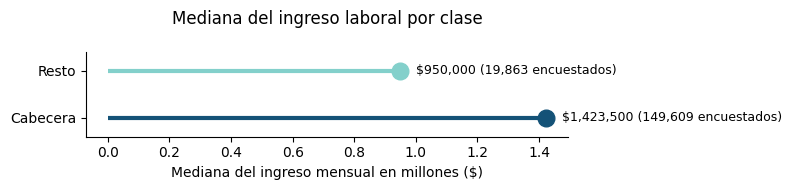

In [86]:
fig, ax = plt.subplots(figsize=(8, 2))

zonas = resumen_zona.index.tolist()
valores = resumen_zona['mediana_ingreso'].values / 1_000_000
cantidades = resumen_zona['cantidad'].values
colores = ['#145277', '#83d0cb']

for i, (zona, valor, cantidad, color) in enumerate(zip(zonas, valores, cantidades, colores)):
    ax.hlines(y=i, xmin=0, xmax=valor, color=color, linewidth=3)
    ax.plot(valor, i, 'o', color=color, markersize=12)
    ax.text(valor + 0.05, i,
            f'${resumen_zona.loc[zona, "mediana_ingreso"]:,.0f} ({cantidad:,} encuestados)',
            va='center', fontsize=9)

ax.set_yticks(range(len(zonas)))
ax.set_yticklabels(zonas, fontsize=10)
ax.set_ylim(-0.4, 1.4)
ax.set_xlabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral por clase', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

La zona de residencia tiene un impacto significativo en el ingreso. Las personas en cabecera tienen una mediana de \$1,423,500, mientras que en resto es de $950,000, una diferencia del 33.3%.

Esto significa que la mitad de los trabajadores en resto gana menos de $950,000, muy por debajo del salario mínimo. Además, resto representa solo el 11.7% de los encuestados (19,863 personas), lo que refleja que la mayor parte del empleo se concentra en las cabeceras municipales.

Este hallazgo se conecta con los anteriores: en resto se concentran los sectores peor pagados (agricultura, hogares como empleadores) y las posiciones más informales (cuenta propia, jornaleros), donde además vimos que la brecha de género es mayor. Es decir, vivir fuera de las cabeceras municipales amplifica todas las desventajas que hemos identificado.

### Pregunta 7: ¿Tener contrato escrito implica ganar más?

Analizamos si el tipo de contrato (sin contrato, verbal, escrito fijo, escrito indefinido) influye en el ingreso laboral. La hipótesis es que mayor formalidad contractual se asocia con mayor ingreso.

In [87]:
# Combinar TIENE_CONTRATO, TIPO_CONTRATO y DURACION_CONTRATO en una sola categoría
def contrato_completo(row):
    if row['TIENE_CONTRATO'] == 'No' or pd.isna(row['TIENE_CONTRATO']):
        return 'Sin contrato'
    elif row['TIPO_CONTRATO'] == 'Verbal':
        return 'Verbal'
    elif row['TIPO_CONTRATO'] == 'Escrito':
        if row['DURACION_CONTRATO'] == 'Indefinido':
            return 'Escrito indefinido'
        elif row['DURACION_CONTRATO'] == 'Fijo':
            return 'Escrito fijo'
        else:
            return 'Escrito (otro)'
    else:
        return 'No especificado'

datos['CONTRATO'] = datos.apply(contrato_completo, axis=1)

orden_contrato = ['Sin contrato', 'Verbal', 'Escrito fijo', 'Escrito indefinido']
resumen_contrato = datos[datos['CONTRATO'].isin(orden_contrato)].groupby('CONTRATO').agg(
    mediana_ingreso=('INGLABO', 'median'),
    cantidad=('INGLABO', 'count')
).reindex(orden_contrato)

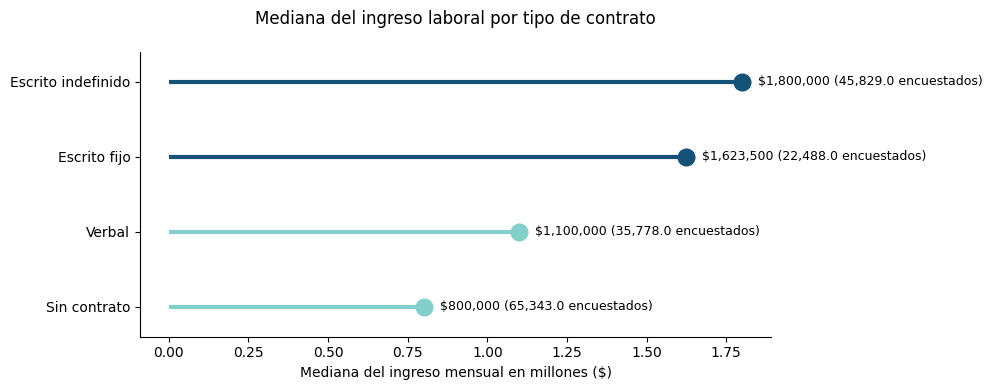

In [88]:
fig, ax = plt.subplots(figsize=(10, 4))

colores = ['#83d0cb', '#83d0cb', '#145277', '#145277']

for i, (contrato, row) in enumerate(resumen_contrato.iterrows()):
    valor = row['mediana_ingreso'] / 1_000_000
    ax.hlines(y=i, xmin=0, xmax=valor, color=colores[i], linewidth=3)
    ax.plot(valor, i, 'o', color=colores[i], markersize=12)
    ax.text(valor + 0.05, i,
            f'${row["mediana_ingreso"]:,.0f} ({row["cantidad"]:,} encuestados)',
            va='center', fontsize=9)

ax.set_yticks(range(len(resumen_contrato)))
ax.set_yticklabels(resumen_contrato.index, fontsize=10)
ax.set_xlabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral por tipo de contrato', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.4, 3.4)

plt.tight_layout()
plt.show()

#### Hallazgos

El tipo de contrato tiene una relación clara con el ingreso: a mayor formalidad contractual, mayor ingreso. Una persona con contrato escrito indefinido \$1.800.000 gana más del doble que una sin contrato \$800.000.

Los datos muestran una escalera clara: sin contrato (\$800,000) → verbal (\$1,100,000) → escrito fijo (\$1,623,500) → escrito indefinido ($1,800,000). Solo los contratos escritos superan el salario mínimo.

Lo más preocupante es que la categoría más grande es precisamente "sin contrato" con 65,343 personas, es decir, el 38.6% de los encuestados trabaja sin ningún tipo de contrato y con una mediana de ingreso casi la mitad del salario mínimo. Si sumamos los de contrato verbal (35,778), más de 100,000 personas, el 59.7% trabaja sin un contrato escrito y con ingresos por debajo del SMLV.

La formalidad contractual es claramente un factor que influye en el ingreso: tener contrato escrito se asocia con ganar más. Sin embargo, queda la pregunta de si esto se debe al contrato en sí o a que los sectores y posiciones que ofrecen contratos escritos son los que mejor pagan.

In [89]:
resumen_sector2 = datos.groupby('SECTOR_ECONOMICO').agg(
    Encuestados=('INGLABO', 'count'),
    Mediana_ingreso=('INGLABO', 'median'),
    Pct_escrito=('CONTRATO', lambda x: round((x.isin(['Escrito fijo', 'Escrito indefinido'])).sum() / len(x) * 100, 1))
).sort_values('Mediana_ingreso', ascending=False)

resumen_sector2['Mediana_ingreso'] = resumen_sector2['Mediana_ingreso'].apply(lambda x: f'${x:,.0f}')
resumen_sector2['Pct_escrito'] = resumen_sector2['Pct_escrito'].apply(lambda x: f'{x}%')
resumen_sector2.columns = ['Encuestados', 'Mediana ingreso', '% con contrato escrito']

resumen_sector2

,Encuestados,Mediana ingreso,% con contrato escrito
SECTOR_ECONOMICO,,,
Actividades de organizaciones y entidades extraterritoriales,45,"$3,200,000",97.8%
Administración pública y defensa; planes de seguridad social de afiliación obligatoria,7520,"$3,000,000",99.3%
Educación,8948,"$2,847,000",87.8%
"Suministro de electricidad, gas, vapor y aire acondicionado",767,"$2,000,000",98.2%
"Actividades profesionales, científicas y técnicas",4748,"$2,000,000",42.0%
Actividades financieras y de seguros,2662,"$2,000,000",83.4%
Información y comunicaciones,2349,"$1,900,000",80.5%
Actividades de atención de la salud humana y de asistencia social,9000,"$1,700,000",86.4%
No clasificado,4,"$1,570,000",50.0%


#### Hallazgos

El tipo de contrato tiene una relación clara con el ingreso: a mayor formalidad contractual, mayor ingreso. Una persona con contrato escrito indefinido gana más del doble que una sin contrato. Solo los contratos escritos superan el salario mínimo.

Más del 59% de los trabajadores no tiene contrato escrito y sus ingresos están por debajo del SMLV.

Al cruzar sector económico con porcentaje de contratos escritos, la relación se confirma: los sectores que mejor pagan son también los que más formalizan a sus trabajadores, y los que peor pagan son los que menos contratos escritos ofrecen. La informalidad contractual y el bajo ingreso van de la mano.

### Pregunta 8: ¿Qué departamentos tienen mayores ingresos?

Comparamos la mediana del ingreso laboral por departamento para identificar las diferencias regionales en el país.

In [103]:
resumen_dpto = datos.groupby('DEPARTAMENTO').agg(
    mediana_ingreso=('INGLABO', 'median'),
    Encuestados=('INGLABO', 'count'),
    Pct_sin_contrato=('CONTRATO', lambda x: round((x == 'Sin contrato').sum() / len(x) * 100, 1)),
    Pct_contrato_escrito=('CONTRATO', lambda x: round((x.isin(['Escrito fijo', 'Escrito indefinido'])).sum() / len(x) * 100, 1)),
    LATITUD=('LATITUD', 'first'),
    LONGITUD=('LONGITUD', 'first')
).reset_index()

fig = px.scatter_mapbox(
    resumen_dpto,
    lat='LATITUD', lon='LONGITUD',
    size='mediana_ingreso',
    color='mediana_ingreso',
    hover_name='DEPARTAMENTO',
    hover_data={
        'mediana_ingreso': ':,.0f',
        'Encuestados': ':,',
        'Pct_sin_contrato': ':.1f',
        'Pct_contrato_escrito': ':.1f',
        'LATITUD': False,
        'LONGITUD': False
    },
    labels={
        'mediana_ingreso': 'Mediana ingreso',
        'Pct_sin_contrato': '% Sin contrato',
        'Pct_contrato_escrito': '% Contrato escrito'
    },
    color_continuous_scale='Teal',
    size_max=35,
    zoom=4.5,
    center={'lat': 4.5, 'lon': -74},
    mapbox_style='carto-positron',
    title='Mediana del ingreso laboral por departamento'
)

fig.update_layout(height=750,title={
        'text': '<b>Mediana del ingreso laboral por departamento</b>',
        'x': 0.5,
        'font': {'size': 25}
    })
fig.show()

#### Hallazgos

Las diferencias de ingreso entre departamentos no son tan extremas como las de educación o tipo de contrato: la mayoría se encuentra entre \$1,000,000 y $1,600,000. El caso más extremo es Sucre (\$800,000) frente a Vaupés (\$1,800,000).

Sin embargo, al agregar el tipo de contrato la relación se hace evidente. Los 5 departamentos con mayor ingreso tienen entre 19% y 32% de trabajadores sin contrato y entre 46% y 68% con contrato escrito. Los 5 con menor ingreso tienen entre 31% y 55% sin contrato y entre 25% y 36% con contrato escrito.

Sucre, el departamento con menor mediana de ingreso (\$800,000), tiene el mayor porcentaje de trabajadores sin contrato (54.8%) y el menor con contrato escrito (25.2%). Vaupés, con la mayor mediana (\$1,800,000), invierte esa proporción: solo 19.2% sin contrato y 51.1% con contrato escrito.

Esto confirma que la diferencia entre departamentos no se explica tanto por la ubicación geográfica sino por el nivel de formalidad laboral de cada región. El tipo de contrato sigue siendo uno de los factores más determinantes del ingreso, independientemente del departamento.

### Pregunta 9: ¿La posición ocupacional influye en el ingreso?

Comparamos la mediana del ingreso laboral según la posición ocupacional (empleado particular, cuenta propia, empleado gobierno, etc.) para ver cómo el tipo de relación laboral afecta el ingreso.

In [118]:
resumen_posicion = datos.groupby('POSICION').agg(
    mediana_ingreso=('INGLABO', 'median'),
    Encuestados=('INGLABO', 'count'),
    Pct_sin_contrato=('CONTRATO', lambda x: round((x == 'Sin contrato').sum() / len(x) * 100, 1)),
    Pct_cotiza_pension=('COTIZA_PENSION', lambda x: round((x == 'Sí').sum() / len(x) * 100, 1)),
    Pct_tiene_ARL=('TIENE_ARL', lambda x: round((x == 'Sí').sum() / len(x) * 100, 1))
).reset_index()

fig = px.treemap(
    resumen_posicion,
    path=['POSICION'],
    values='Encuestados',
    color='mediana_ingreso',
    color_continuous_scale='Teal',
    labels={'mediana_ingreso': 'Mediana ingreso', 'POSICION': 'Posición'},
)

fig.update_traces(
    marker=dict(line=dict(width=0)),
    customdata=resumen_posicion[['mediana_ingreso', 'Encuestados', 'Pct_sin_contrato', 'Pct_cotiza_pension', 'Pct_tiene_ARL']].values,
    hovertemplate='<b>%{label}</b><br>'
                  'Encuestados: %{customdata[1]:,}<br>'
                  'Mediana ingreso: $%{customdata[0]:,.0f}<br>'
                  'Sin contrato: %{customdata[2]}%<br>'
                  'Cotiza pensión: %{customdata[3]}%<br>'
                  'Tiene ARL: %{customdata[4]}%<extra></extra>'
)

fig.update_layout(
    height=500,
    title={
        'text': '<b>Ingreso y cantidad de trabajadores por posición ocupacional</b>',
        'x': 0.5,
        'font': {'size': 16}
    }
)

fig.show()

#### Hallazgos

La posición ocupacional influye directamente en el ingreso. La posición con más trabajadores en Colombia es Cuenta propia con 73,717 personas, y es también una de las que menos paga: su mediana es de \$900,000, por debajo del salario mínimo. Además, solo el 14.6% cotiza pensión y el 13.3% tiene ARL, lo que significa que la mayoría de estos trabajadores no tendrá jubilación ni está cubierto ante un accidente laboral.

Esto plantea un problema estructural: casi la mitad de la fuerza laboral colombiana trabaja por cuenta propia, con bajos ingresos y sin protección social. Cualquier política pública o estrategia empresarial que busque mejorar los ingresos de los colombianos necesita enfocarse en esta población, ya sea facilitando su formalización o creando mecanismos de protección adaptados a su realidad laboral.

### Pregunta 10: ¿Las horas trabajadas correlacionan con el ingreso?

Analizamos si trabajar más horas se traduce en ganar más.

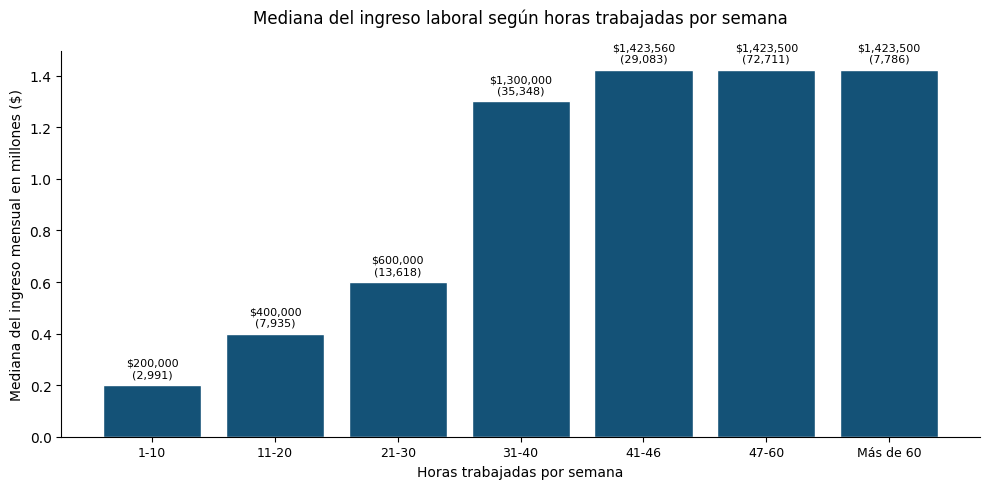

In [133]:
bins_horas = [0, 10, 20, 30, 40, 46, 60, 200]
labels_horas = ['1-10', '11-20', '21-30', '31-40', '41-46', '47-60', 'Más de 60']

datos['RANGO_HORAS'] = pd.cut(datos['HORAS_SEMANA'], bins=bins_horas, labels=labels_horas)

resumen_horas = datos.groupby('RANGO_HORAS').agg(
    mediana_ingreso=('INGLABO', 'median'),
    Encuestados=('INGLABO', 'count')
)

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(range(len(resumen_horas)), resumen_horas['mediana_ingreso'] / 1_000_000,
                color='#145277', edgecolor='white')

for i, (ingreso, cantidad) in enumerate(zip(resumen_horas['mediana_ingreso'], resumen_horas['Encuestados'])):
    ax.text(i, ingreso / 1_000_000 + 0.03,
            f'${ingreso:,.0f}\n({cantidad:,})', ha='center', fontsize=8)

ax.set_xticks(range(len(resumen_horas)))
ax.set_xticklabels(labels_horas, fontsize=9)
ax.set_xlabel('Horas trabajadas por semana')
ax.set_ylabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral según horas trabajadas por semana', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

Las horas trabajadas influyen en el ingreso, pero solo hasta cierto punto. De 1 a 46 horas semanales el ingreso sube de forma proporcional: quien trabaja 41-46 horas (\$1,423,500) gana 7 veces más que quien trabaja 1-10 horas (\$200,000).

Sin embargo, a partir de las 46 horas (la jornada legal vigente durante el primer semestre de 2025) el ingreso se estanca. Trabajar 49-60 horas (\$1,400,000) o más de 60 horas (\$1,423,500) no representa una mejora frente a trabajar 41-48 horas. Es decir, más de 34,000 personas trabajan más de la jornada legal sin recibir mayor ingreso por ello.

Esto sugiere que quienes trabajan pocas horas probablemente tienen empleos de tiempo parcial o informales, y quienes trabajan más de la jornada legal no están recibiendo compensación por esas horas adicionales, lo que puede estar asociado a la informalidad que hemos identificado a lo largo del análisis.

### Pregunta 11: ¿La antigüedad en la empresa influye en el ingreso?

Analizamos si llevar más tiempo trabajando en la misma empresa se traduce en un mayor ingreso laboral.

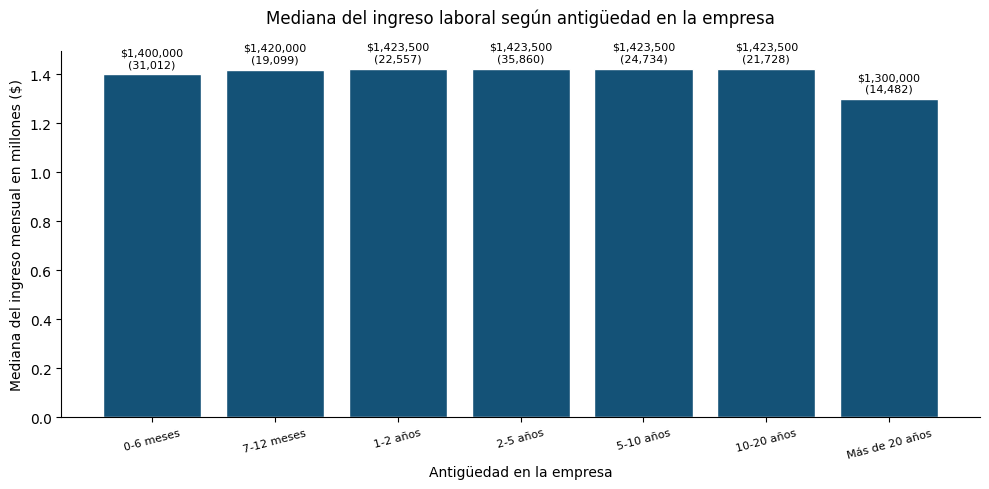

In [134]:
bins_ant = [0, 6, 12, 24, 60, 120, 240, 1000]
labels_ant = ['0-6 meses', '7-12 meses', '1-2 años', '2-5 años', '5-10 años', '10-20 años', 'Más de 20 años']

datos['RANGO_ANTIGUEDAD'] = pd.cut(datos['ANTIGUEDAD_MESES'], bins=bins_ant, labels=labels_ant, include_lowest=True)

resumen_ant = datos.groupby('RANGO_ANTIGUEDAD').agg(
    mediana_ingreso=('INGLABO', 'median'),
    Encuestados=('INGLABO', 'count')
)

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(range(len(resumen_ant)), resumen_ant['mediana_ingreso'] / 1_000_000,
                color='#145277', edgecolor='white')

for i, (ingreso, cantidad) in enumerate(zip(resumen_ant['mediana_ingreso'], resumen_ant['Encuestados'])):
    ax.text(i, ingreso / 1_000_000 + 0.03,
            f'${ingreso:,.0f}\n({cantidad:,})', ha='center', fontsize=8)

ax.set_xticks(range(len(resumen_ant)))
ax.set_xticklabels(labels_ant, fontsize=8, rotation=15)
ax.set_xlabel('Antigüedad en la empresa')
ax.set_ylabel('Mediana del ingreso mensual en millones ($)')
ax.set_title('Mediana del ingreso laboral según antigüedad en la empresa', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Hallazgos

La antigüedad en la empresa prácticamente no influye en el ingreso. La mediana se mantiene estable alrededor de \$1,423,500 desde los 7 meses hasta los 20 años. Incluso las personas con más de 20 años en la misma empresa tienen una mediana menor (\$1,300,000) que quienes llevan apenas 1 o 2 años.

Esto contradice la idea de que "entre más tiempo lleves en una empresa, más ganas". En Colombia, la antigüedad por sí sola no se traduce en mayor ingreso. Lo que determina cuánto gana una persona, como hemos visto a lo largo de este análisis, son otros factores: el nivel educativo, el tipo de contrato, la posición ocupacional y el sector económico.

### Conclusión general
#### ¿Qué factores determinan el ingreso laboral en Colombia?

Después de analizar 169,472 registros de la GEIH del primer semestre de 2025, identificamos tres factores que tienen mayor influencia directa en el ingreso laboral:

**1. Nivel educativo:** es el factor más determinante. Una persona con doctorado tiene una mediana de ingreso 7 veces mayor que una con básica primaria. Solo a partir del nivel tecnológico la mediana supera el salario mínimo, pero la mayoría de los trabajadores (más del 59%) tiene nivel de media académica o inferior, lo que explica por qué la mediana nacional está tan cerca del SMLV.

**2. Tipo de contrato y formalidad:** quienes tienen contrato escrito indefinido ganan más del doble que quienes no tienen contrato. Más del 59% de los trabajadores no tiene contrato escrito. Además, al cruzar sectores con porcentaje de contratos escritos, se confirma que los sectores que más formalizan son los que mejor pagan.

**3. Sector económico:** 14 de los 22 sectores tienen medianas iguales o inferiores al salario mínimo, y concentran el 78.7% de los trabajadores. Los sectores mejor pagados (administración pública, educación, actividades profesionales) son los que exigen mayor formación y ofrecen mayor formalidad.

Estos tres factores no actúan de forma aislada sino que se refuerzan entre sí: menor educación lleva a empleos en sectores informales, que a su vez ofrecen menos contratos escritos y menores ingresos.

#### Observaciones complementarias

**Sexo:** la brecha general entre hombres y mujeres es de apenas 1.7%, lo que no permite afirmar que el sexo determine directamente el ingreso. Sin embargo, al controlar por nivel educativo aparecen brechas de hasta 45% en los niveles más bajos, y las mujeres están sobrerrepresentadas en posiciones de menor ingreso como el empleo doméstico. La brecha salarial por género está más asociada al tipo de posiciones que ocupan hombres y mujeres que al sexo en sí mismo.

**Horas trabajadas:** las horas dentro de la jornada legal (46 horas semanales en el primer semestre de 2025) se encuentran remuneradas de acuerdo al SMLV. Sin embargo, trabajar más horas no implica necesariamente un mejor salario: más de 34,000 personas trabajan por encima de la jornada legal con la misma mediana de ingreso que quienes trabajan 41-46 horas.

**Antigüedad en la empresa:** contrario a lo esperado, llevar más tiempo en una empresa no se traduce en mayor ingreso. La mediana se mantiene prácticamente igual desde los 7 meses hasta los 20 años.

**Zona geográfica:** la diferencia entre cabecera (\$1,423,500) y resto (\$950,000) es significativa, pero se explica por la concentración de informalidad y los sectores predominantes en cada zona, no por la ubicación en sí misma.

**Departamento:** las diferencias entre departamentos son moderadas comparadas con los otros factores. Los departamentos con menores ingresos son los que tienen mayor porcentaje de trabajadores sin contrato, confirmando que la formalidad es un factor transversal.

#### ¿Qué significa esto para la toma de decisiones?

El mercado laboral colombiano presenta un problema estructural: la mayoría de los trabajadores se concentra en posiciones informales, en sectores de bajo ingreso y con niveles educativos que no alcanzan para superar el salario mínimo. Estos factores se refuerzan mutuamente creando un ciclo difícil de romper.

Los datos sugieren que las intervenciones más efectivas para mejorar el ingreso laboral serían: facilitar el acceso a educación técnica y tecnológica (el salto más grande de ingreso ocurre entre media académica y nivel tecnológico), incentivar la formalización laboral especialmente en los trabajadores por cuenta propia (que representan casi la mitad de la fuerza laboral), y fortalecer la regulación en los sectores con mayor informalidad.

---
*Proyecto: Factores que determinan el ingreso laboral en Colombia | GEIH 2025 | Katherin Reyes*